# Notebook 7: Mapper and fMapper for Shape-Based Data Analysis

**Author:** Alejandro Ucan

This notebook follows the same pedagogical style as N0_Isomap and focuses on how to build, tune, and interpret Mapper-style topological graphs.

## Learning Objectives

By the end of this notebook, you should be able to:
1. Explain the Mapper pipeline and its key hyperparameters.
2. Build Mapper graphs on nonlinear datasets and inspect their topology.
3. Use a function-guided variant (fMapper) with a learned lens.
4. Compare Mapper and fMapper under different hyperparameter settings.
5. Interpret graph structure, loops, bridges, and cluster composition.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Instalación de librerías necesarias
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: Instala las librerías que usaremos en todo el notebook
#   - kmapper: implementación oficial de Mapper (KeplerMapper)
#   - umap-learn: UMAP para usar como lens en fMapper
#   - networkx: manipulación y análisis de grafos
# ═══════════════════════════════════════════════════════════════

%pip install -q "kmapper>=2.1.0" "umap-learn>=0.5.7" networkx

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELDA 2 — Imports de librerías
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: Importa todo lo que el notebook necesita para:
#   - construir el grafo de Mapper (kmapper)
#   - graficar el grafo (networkx + matplotlib)
#   - generar datasets de prueba (sklearn.datasets)
#   - hacer clustering local (DBSCAN, MiniBatchKMeans)
#   - reducir dimensionalidad para fMapper (umap)
#   - evaluar calidad (silhouette, cross_val_score)
# ═══════════════════════════════════════════════════════════════

import warnings

import kmapper as km                # librería principal de Mapper
import matplotlib.pyplot as plt     # para graficar
import networkx as nx               # para manipular el grafo resultante
import numpy as np                  # operaciones numéricas
import pandas as pd                 # tablas para barrido de hiperparámetros
import umap                         # UMAP como lens en fMapper

# Algoritmos de clustering local (usados DENTRO de cada intervalo del cover)
from sklearn.cluster import DBSCAN, MiniBatchKMeans

# Datasets de prueba: círculos concéntricos, medias lunas, Swiss roll, iris
from sklearn.datasets import load_iris, make_circles, make_moons, make_swiss_roll

# PCA como baseline de comparación
from sklearn.decomposition import PCA

# Métricas para evaluar calidad de clustering
from sklearn.metrics import silhouette_score

# Validación cruzada para evaluar clasificador sobre PCA
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Estandarización de datos (media 0, varianza 1)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")   # silencia warnings para que no estorben
np.random.seed(7)                    # semilla fija → resultados reproducibles

In [3]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3 — Configuración visual (paleta de colores y estilo)
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: Define colores consistentes y una función auxiliar
# para que todas las gráficas del notebook se vean iguales
# ═══════════════════════════════════════════════════════════════

# Paleta de colores usada en todas las gráficas
PALETTE = {
    "blue":   "#3f72af",   # azul principal (Mapper)
    "orange": "#f4a261",   # naranja (PCA baseline)
    "green":  "#2a9d8f",   # verde (fMapper)
    "red":    "#e76f51",   # rojo (énfasis/alertas)
    "bg":     "#f6f7fb",   # color de fondo
}

# Configuración global de matplotlib — aplica a TODAS las gráficas
plt.rcParams.update({
    "figure.figsize": (10, 6),       # tamaño default de las figuras
    "axes.grid": True,                # grilla de fondo activada
    "grid.alpha": 0.3,                # grilla con transparencia (sutil)
    "grid.linestyle": "--",          # grilla con líneas punteadas
    "font.size": 11,                  # tamaño de letra base
})

def beautify(ax, title=None, xlabel=None, ylabel=None):
    """
    Función auxiliar que aplica el estilo visual a un subplot.
    Se usa en casi todas las gráficas del notebook para evitar
    repetir código de formato.
    """
    ax.set_facecolor(PALETTE["bg"])   # fondo con el color de la paleta
    if title is not None:
        ax.set_title(title, fontsize=12, pad=10)  # título con padding
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

## 1. Why Mapper?

PCA gives linear projections. But many datasets live on nonlinear manifolds where geometry and topology (components, loops, bridges) matter.

Mapper builds a graph summary of shape by combining:
1. A lens function $f: X \to \mathbb{R}^m$
2. An overlapping cover of the lens space
3. Local clustering inside each cover element
4. A graph where nodes are local clusters and edges connect overlapping clusters

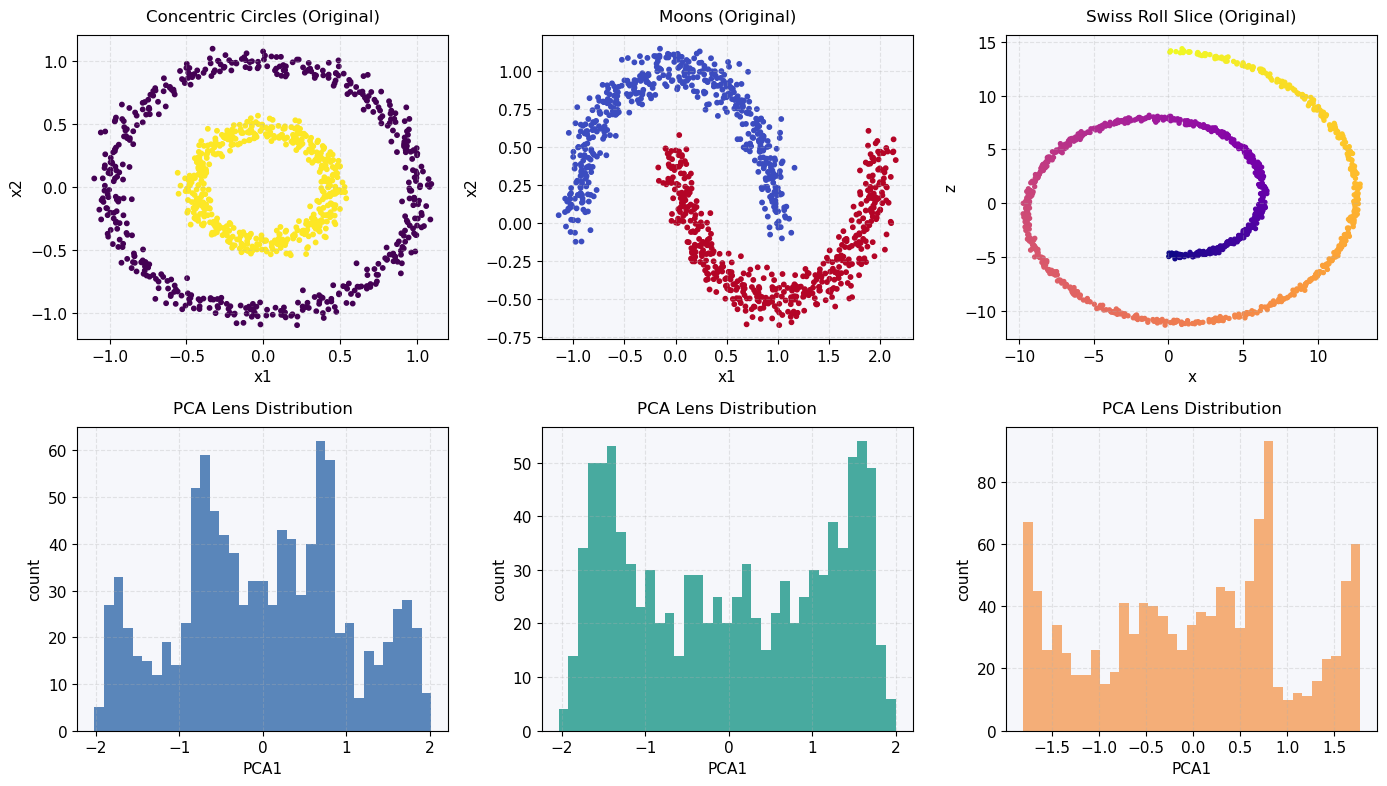

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Generación de datasets + visualización con PCA como lens
# ═══════════════════════════════════════════════════════════════
# CONTENIDO:
#   1. Genera 3 datasets no lineales clásicos:
#      - Círculos concéntricos (topología: 2 loops)
#      - Medias lunas (topología: 2 arcos entrelazados)
#      - Swiss roll (topología: hoja enrollada)
#   2. Los grafica en su forma original
#   3. Les aplica PCA reduciendo a 1D (esto SIMULA una lens)
#   4. Muestra el histograma de esa proyección 1D
#
# OBJETIVO: visualizar cómo se vería el eje sobre el que el cover
# va a dividir los datos en intervalos. La DISTRIBUCIÓN de esta
# proyección determina qué puntos caen en cada intervalo.
# ═══════════════════════════════════════════════════════════════

# ── Generar los tres datasets ────────────────────────────────
# make_circles: dos círculos concéntricos con ruido pequeño
# factor=0.45 → el círculo interno tiene 45% del radio del externo
X_circles, y_circles = make_circles(n_samples=1000, factor=0.45, noise=0.05, random_state=7)

# make_moons: dos medias lunas entrelazadas
X_moons,   y_moons   = make_moons(n_samples=1000, noise=0.08, random_state=7)

# make_swiss_roll: hoja 2D enrollada en 3D
X_swiss,   t_swiss   = make_swiss_roll(n_samples=1200, noise=0.12, random_state=7)

# Para el swiss roll tomamos solo X y Z (ignorando Y) → vista 2D del rollo
X_swiss_2d = X_swiss[:, [0, 2]]

# ── Crear figura con 2 filas × 3 columnas ───────────────────
#    Fila superior: dataset original
#    Fila inferior: histograma de su proyección PCA (futura lens)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# ── Columna 1: Círculos concéntricos ─────────────────────────
axes[0, 0].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, s=10, cmap="viridis")
beautify(axes[0, 0], "Concentric Circles (Original)", "x1", "x2")

# PCA 1D → proyecta a una sola dirección = direcciones de máxima varianza
# StandardScaler primero para que PCA funcione correctamente
pca_c = PCA(n_components=1).fit_transform(StandardScaler().fit_transform(X_circles))
axes[1, 0].hist(pca_c[:, 0], bins=35, color=PALETTE["blue"], alpha=0.85)
beautify(axes[1, 0], "PCA Lens Distribution", "PCA1", "count")

# ── Columna 2: Medias lunas ──────────────────────────────────
axes[0, 1].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, s=10, cmap="coolwarm")
beautify(axes[0, 1], "Moons (Original)", "x1", "x2")

pca_m = PCA(n_components=1).fit_transform(StandardScaler().fit_transform(X_moons))
axes[1, 1].hist(pca_m[:, 0], bins=35, color=PALETTE["green"], alpha=0.85)
beautify(axes[1, 1], "PCA Lens Distribution", "PCA1", "count")

# ── Columna 3: Swiss roll ────────────────────────────────────
# Coloreamos por t_swiss (el parámetro del enrollado) → gradiente suave
axes[0, 2].scatter(X_swiss_2d[:, 0], X_swiss_2d[:, 1], c=t_swiss, s=8, cmap="plasma")
beautify(axes[0, 2], "Swiss Roll Slice (Original)", "x", "z")

pca_s = PCA(n_components=1).fit_transform(StandardScaler().fit_transform(X_swiss_2d))
axes[1, 2].hist(pca_s[:, 0], bins=35, color=PALETTE["orange"], alpha=0.85)
beautify(axes[1, 2], "PCA Lens Distribution", "PCA1", "count")

plt.tight_layout()
plt.show()
# Lo que esperamos ver: cada dataset con una distribución diferente
# en su proyección PCA 1D → el cover usará ESE eje para dividir.

## 2. Mapper Algorithm

Given data $X$, a lens $f$, and a cover $\mathcal{U}=\{U_i\}$ of $f(X)$:
1. Compute pullback sets $f^{-1}(U_i)$.
2. Cluster each pullback set.
3. Create one node per local cluster.
4. Connect nodes if their clusters share at least one data point.

Core hyperparameters:
- `projection` (lens): what geometric information is emphasized
- `n_cubes`: number of intervals/boxes in the cover
- `perc_overlap`: overlap between intervals
- `clusterer` and its parameters (DBSCAN/KMeans/etc.)

Mapper stats: {'nodes': 26, 'edges': 26, 'components': 2, 'cycles': 2, 'avg_degree': 2.0}


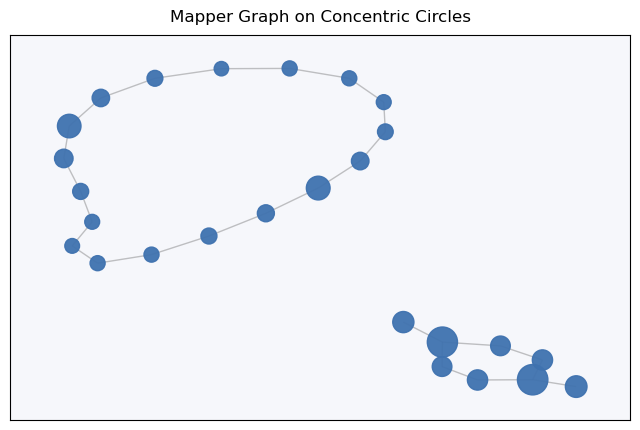

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Funciones base del pipeline de Mapper
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: 4 funciones auxiliares que usaremos todo el notebook:
#   1. mapper_to_networkx(): convierte el dict de kmapper en un
#      grafo de networkx (más fácil de analizar)
#   2. graph_stats(): calcula estadísticas topológicas del grafo
#      incluyendo β₀ (componentes) y β₁ (ciclos por Euler)
#   3. draw_mapper_graph(): dibuja el grafo con nodos
#      proporcionales al tamaño del cluster
#   4. build_mapper(): el pipeline completo de Mapper en una función
#
# También aplica el pipeline a los círculos concéntricos como demo.
# ═══════════════════════════════════════════════════════════════

def mapper_to_networkx(graph_dict):
    """
    Convierte el diccionario que devuelve kmapper en un grafo networkx.
    
    kmapper devuelve: {"nodes": {id: [indices]}, "links": {id: [vecinos]}}
    networkx necesita: G con nodos y aristas como objetos
    
    Hacemos esta conversión porque networkx tiene funciones útiles
    (como number_connected_components, degree, etc.)
    """
    G = nx.Graph()   # grafo vacío
    
    # Agregar cada nodo con su atributo 'size' = número de puntos
    for node, members in graph_dict["nodes"].items():
        G.add_node(node, size=len(members))
        # size es importante para dibujar nodos proporcionales
    
    # Agregar cada arista (conexión entre clusters que comparten puntos)
    for src, dsts in graph_dict["links"].items():
        for dst in dsts:
            G.add_edge(src, dst)
    
    return G


def graph_stats(G):
    """
    Calcula estadísticas topológicas CLAVE del grafo de Mapper:
      - nodes:       número total de nodos (N)
      - edges:       número total de aristas (M)
      - components:  β₀ = cuántas partes desconectadas hay
      - cycles:      β₁ = número de ciclos (fórmula de Euler)
      - avg_degree:  grado promedio (cuántas aristas tiene cada nodo en promedio)
    
    Fórmula de Euler (CLAVE para el examen):
      β₁ = M - N + C
      donde M=aristas, N=nodos, C=componentes conectadas
    """
    n = G.number_of_nodes()            # N = número de nodos
    m = G.number_of_edges()            # M = número de aristas
    
    # C = componentes conectadas (β₀)
    # Si el grafo está vacío → 0 componentes
    c = nx.number_connected_components(G) if n > 0 else 0
    
    # β₁ = ciclos calculados con fórmula de Euler
    # Cada arista extra sobre un árbol expansor = 1 ciclo más
    cycles = m - n + c #LA FORMULA DE EULER
     
    # Grado promedio: en promedio, ¿cuántas aristas tiene cada nodo?
    # G.degree() devuelve [(nodo1, grado1), (nodo2, grado2), ...]
    avg_deg = float(np.mean([d for _, d in G.degree()])) if n > 0 else 0.0
    
    return {
        "nodes":      n,
        "edges":      m,
        "components": c,
        "cycles":     int(cycles),
        "avg_degree": avg_deg,
    }


def draw_mapper_graph(G, title, node_color):
    """
    Dibuja el grafo de Mapper de forma bonita.
    Los nodos tienen TAMAÑO proporcional al número de puntos
    que contienen (atributo 'size').
    """
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Caso borde: grafo vacío (puede pasar si los parámetros son malos)
    if G.number_of_nodes() == 0:
        ax.text(0.5, 0.5, "Empty graph", ha="center", va="center")
        beautify(ax, title)
        plt.show()
        return
    
    # spring_layout: algoritmo de 'fuerzas' que acomoda los nodos
    # como si fueran muelles → nodos conectados cerca, desconectados lejos
    # seed=7 → siempre el mismo layout (reproducible)
    pos = nx.spring_layout(G, seed=7)
    
    # Tamaño de cada nodo: base=55 + 2.5 * (# puntos en el cluster)
    # Así los nodos grandes visualmente = clusters con más puntos
    node_sizes = [55 + 2.5 * G.nodes[n]["size"] for n in G.nodes()]
    
    # Dibujar aristas primero (para que queden debajo de los nodos)
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, width=1.0, edge_color="#555555")
    
    # Dibujar nodos encima
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_sizes, node_color=node_color, alpha=0.95)
    
    beautify(ax, title)
    ax.set_xticks([])   # ejes sin números (el layout es arbitrario)
    ax.set_yticks([])
    plt.show()


def build_mapper(X, lens, n_cubes=10, overlap=0.3, clusterer=None):
    """
    PIPELINE COMPLETO DE MAPPER — la función más importante del notebook.
    
    Pasos internos:
      1. Crear instancia de KeplerMapper
      2. Definir el cover (intervalos solapados sobre la lens)
      3. Llamar mapper.map() que ejecuta los 4 pasos del algoritmo
      4. Convertir el resultado a networkx
    
    Parámetros:
      X:          datos originales (n_samples, n_features)
      lens:       proyección de los datos (n_samples, 1) o (n_samples, 2)
      n_cubes:    cuántos intervalos tiene el cover
      overlap:    fracción de solapamiento entre intervalos (0.3 = 30%)
      clusterer:  algoritmo de clustering local (DBSCAN por default)
    
    Devuelve:
      graph: el diccionario de kmapper (útil para purity)
      Gnx:   el grafo de networkx (útil para análisis)
    """
    # Instancia del Mapper — verbose=0 para no llenar la pantalla de logs
    mapper = km.KeplerMapper(verbose=0)
    
    # Si no se da un clusterer, usar DBSCAN con parámetros default razonables
    # DBSCAN no necesita saber cuántos clusters hay (a diferencia de KMeans)
    if clusterer is None:
        clusterer = DBSCAN(eps=0.25, min_samples=5)
    
    # Cover: divide el rango de la lens en n_cubes intervalos
    # con solapamiento perc_overlap entre intervalos adyacentes
    cover = km.Cover(n_cubes=n_cubes, perc_overlap=overlap)
    
    # mapper.map() ejecuta los 4 pasos del algoritmo:
    #   1. Pullback: qué puntos caen en cada intervalo de la lens
    #   2. Clustering local dentro de cada intervalo
    #   3. Cada cluster → 1 nodo
    #   4. Aristas entre nodos que comparten puntos
    graph = mapper.map(lens, X, clusterer=clusterer, cover=cover)
    
    # Convertir a networkx para facilitar análisis posterior
    Gnx = mapper_to_networkx(graph)
    
    return graph, Gnx


# ═══════════════════════════════════════════════════════════
# DEMO: aplicar Mapper a los círculos concéntricos
# ═══════════════════════════════════════════════════════════

# Paso 1: estandarizar los datos (media 0, varianza 1)
# → importante porque DBSCAN usa distancias absolutas
Xc = StandardScaler().fit_transform(X_circles)

# Paso 2: elegir la lens = coordenada Y
# Xc[:, [1]] → toma solo la columna 1 y la mantiene como matriz (n, 1)
# Esta lens hace que el cover corte horizontalmente los círculos
lens_height = Xc[:, [1]]

# Paso 3: construir el grafo de Mapper
# eps=0.22 es un radio ajustado para que DBSCAN detecte los clusters
# dentro de cada intervalo del cover
graph_mapper, G_mapper = build_mapper(
    Xc,
    lens_height,
    n_cubes=10,                                     # 10 intervalos
    overlap=0.3,                                    # 30% de solapamiento
    clusterer=DBSCAN(eps=0.22, min_samples=6)      # DBSCAN local
)

# Paso 4: calcular estadísticas topológicas
stats_mapper = graph_stats(G_mapper)
print("Mapper stats:", stats_mapper)
# ESPERADO: el grafo debería tener β₁ ≈ 2 (dos ciclos = dos círculos)

# Paso 5: visualizar el grafo
draw_mapper_graph(G_mapper, "Mapper Graph on Concentric Circles", node_color=PALETTE["blue"])

## 3. Mapper Hyperparameter Study

We vary cover resolution and overlap while keeping the same lens and clusterer.

Expected behavior:
- Higher `n_cubes` often increases graph detail (and noise).
- Higher overlap can connect nearby local clusters and reduce fragmentation.

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Barrido de hiperparámetros de Mapper
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: Prueba todas las combinaciones de (n_cubes × overlap)
# sobre los círculos concéntricos y muestra cómo cambian las
# estadísticas del grafo en cada caso.
#
# OBJETIVO: ver cómo los dos parámetros del cover afectan la
# topología del grafo resultante. Entender qué combinación da
# el resultado topológicamente más fiel (β₁ = 2 para dos círculos).
#
# QUÉ SE ESPERA:
#   - n_cubes muy chico → pierde detalle (grafo muy simple)
#   - n_cubes muy grande → ruido (muchos nodos falsos)
#   - overlap muy chico → grafo fragmentado (componentes sueltas)
#   - overlap muy grande → todo conectado (pierde estructura)
# ═══════════════════════════════════════════════════════════════

sweep_rows = []   # lista donde guardaremos cada fila de resultados

# Doble bucle: probar cada combinación de (n_cubes, overlap)
# 3 valores × 3 valores = 9 combinaciones totales
for n_cubes in [6, 10, 16]:          # resolución del cover
    for overlap in [0.15, 0.30, 0.50]:   # solapamiento entre intervalos
        # Construir Mapper con estos parámetros
        # _ = ignoramos el diccionario de kmapper (solo queremos el grafo)
        _, Gtmp = build_mapper(
            Xc,                                        # datos estandarizados
            lens_height,                               # lens = coord Y
            n_cubes=n_cubes,                           # variable
            overlap=overlap,                           # variable
            clusterer=DBSCAN(eps=0.22, min_samples=6) # DBSCAN fijo
        )
        
        # Calcular estadísticas del grafo (nodos, aristas, β₀, β₁, ...)
        st = graph_stats(Gtmp)
        
        # Agregar los valores de hiperparámetros al diccionario de stats
        # para poder identificar cada fila en la tabla final
        st.update({"n_cubes": n_cubes, "overlap": overlap})
        
        sweep_rows.append(st)

# Convertir la lista de diccionarios en un DataFrame de pandas
# sort_values → ordena por n_cubes y overlap para lectura fácil
mapper_sweep = pd.DataFrame(sweep_rows) \
    .sort_values(["n_cubes", "overlap"]) \
    .reset_index(drop=True)

# Mostrar la tabla — observa cómo cambian 'cycles' y 'components'
# con cada combinación
mapper_sweep

,nodes,edges,components,cycles,avg_degree,n_cubes,overlap
0,14,13,2,1,1.857143,6,0.15
1,14,13,2,1,1.857143,6,0.30
2,14,13,2,1,1.857143,6,0.50
3,26,26,2,2,2.000000,10,0.15
4,26,26,2,2,2.000000,10,0.30
5,25,25,2,2,2.000000,10,0.50
6,41,40,2,1,1.951220,16,0.15
7,41,41,2,2,2.000000,16,0.30
8,42,42,2,2,2.000000,16,0.50


overlap pequeño (0.15):
  ✅ más rápido (menos puntos compartidos)
  ✅ grafo más limpio
  ❌ riesgo de fragmentar (componentes sueltas)

overlap grande (0.50):
  ✅ más conexiones → grafo más robusto
  ❌ más lento (más puntos en zona de solapamiento)
  ❌ puede crear conexiones falsas

→ 0.30-0.35 es el balance estándar ✅
→ computacionalmente: overlap grande = más costoso
  porque hay más puntos en cada intervalo → más clustering

## 4. fMapper: Function-Guided Mapper

In this notebook, **fMapper** means a function-guided Mapper variant where the lens $f$ is learned from data (instead of using a raw coordinate).

We use a 1D UMAP lens and a fast local clusterer (MiniBatchKMeans):
- Mapper: simple coordinate lens, DBSCAN local clusters
- fMapper: learned nonlinear lens, mini-batch local clusters

This often produces a cleaner global organization when the intrinsic geometry is highly nonlinear.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


fMapper stats: {'nodes': 24, 'edges': 17, 'components': 8, 'cycles': 1, 'avg_degree': 1.4166666666666667}


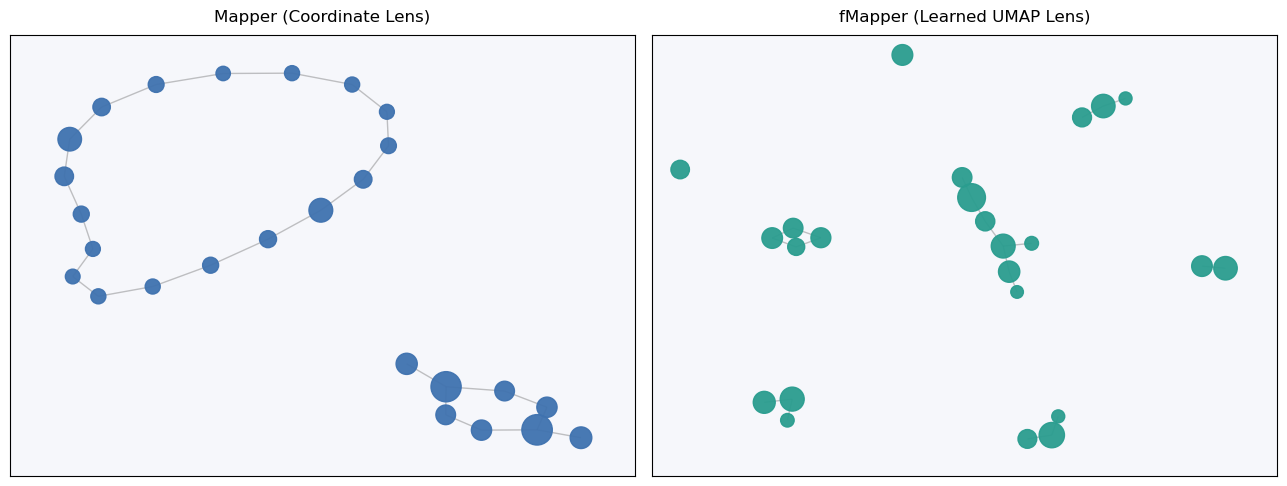

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELDA 7 — fMapper: Mapper con lens aprendida por UMAP
# ═══════════════════════════════════════════════════════════════
# CONTENIDO:
#   1. Entrena UMAP para reducir los datos a 1D → esa es la lens
#   2. Construye Mapper usando esa lens no-lineal
#   3. Compara visualmente el grafo Mapper vs fMapper
#
# DIFERENCIA CON MAPPER NORMAL:
#   - Mapper:  lens = coordenada simple (Y) → lineal
#   - fMapper: lens = UMAP 1D → NO LINEAL, aprende la geometría real
#
# QUÉ SE ESPERA:
#   - fMapper captura mejor la estructura nolineal de los círculos
#   - El grafo resultante es más limpio
# ═══════════════════════════════════════════════════════════════

# ── Paso 1: crear la lens con UMAP ──────────────────────────
# n_components=1 → proyectamos a 1D (como un eje)
# n_neighbors=20 → cada punto considera 20 vecinos locales
# min_dist=0.15 → balance entre compactación y dispersión
reducer = umap.UMAP(
    n_components=1,
    n_neighbors=20,
    min_dist=0.15,
    random_state=7   # reproducibilidad
)

# fit_transform: entrena UMAP sobre Xc y devuelve la proyección
# lens_f ahora es un array (1000, 1) — la lens aprendida
lens_f = reducer.fit_transform(Xc)

# ── Paso 2: construir Mapper con esta lens ──────────────────
# Usamos MiniBatchKMeans en lugar de DBSCAN:
#   - Más rápido para datasets grandes
#   - n_clusters=2 → fuerza exactamente 2 clusters dentro de cada intervalo
#     (apropiado para círculos: interior y exterior)
graph_fmapper, G_fmapper = build_mapper(
    Xc,
    lens_f,                                                    # lens UMAP
    n_cubes=12,                                                # 12 intervalos
    overlap=0.35,                                              # 35% solapamiento
    clusterer=MiniBatchKMeans(n_clusters=2, random_state=7, batch_size=128),
)

# ── Paso 3: imprimir estadísticas topológicas ───────────────
print("fMapper stats:", graph_stats(G_fmapper))
# ESPERADO: algo similar a Mapper pero posiblemente más limpio


¿Por qué fMapper es peor aquí?
  Los parámetros de UMAP no eran óptimos para este dataset
  → n_neighbors=20 con min_dist=0.15 fragmentó la lens
  → el cover cortó mal → clusters sueltos
  → fMapper NO siempre es mejor que Mapper
  → depende de los parámetros


Lección importante:
  fMapper es mejor cuando los datos son muy no-lineales
  Mapper simple puede ser suficiente cuando la lens
  ya captura bien la estructura (como la altura Y aquí)

In [ ]:

# ── Paso 4: comparar visualmente Mapper vs fMapper ──────────
# Creamos figura con 2 subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Subplot izquierdo: Mapper original (coord Y) ────────────
pos1 = nx.spring_layout(G_mapper, seed=7)  # layout por fuerzas

# Dibujar aristas
nx.draw_networkx_edges(G_mapper, pos1, ax=axes[0], alpha=0.35, width=1.0, edge_color="#555555")

# Dibujar nodos — tamaño proporcional al atributo 'size'
nx.draw_networkx_nodes(
    G_mapper,
    pos1,
    ax=axes[0],
    node_size=[55 + 2.5 * G_mapper.nodes[n]["size"] for n in G_mapper.nodes()],
    node_color=PALETTE["blue"],
    alpha=0.95,
)
beautify(axes[0], "Mapper (Coordinate Lens)")
axes[0].set_xticks([])
axes[0].set_yticks([])

# ── Subplot derecho: fMapper (lens UMAP) ─────────────────────
pos2 = nx.spring_layout(G_fmapper, seed=7)
nx.draw_networkx_edges(G_fmapper, pos2, ax=axes[1], alpha=0.35, width=1.0, edge_color="#555555")
nx.draw_networkx_nodes(
    G_fmapper,
    pos2,
    ax=axes[1],
    node_size=[55 + 2.5 * G_fmapper.nodes[n]["size"] for n in G_fmapper.nodes()],
    node_color=PALETTE["green"],
    alpha=0.95,
)
beautify(axes[1], "fMapper (Learned UMAP Lens)")
axes[1].set_xticks([])
axes[1].set_yticks([])

plt.tight_layout()
plt.show()

## 5. fMapper Hyperparameter Study

Now we study how lens hyperparameters change graph topology.

fMapper lens parameters:
- `n_neighbors`: local vs global balance in UMAP lens
- `min_dist`: compactness of UMAP embedding

Mapper cover parameters still matter:
- `n_cubes`, `overlap`

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 8 — Barrido de hiperparámetros de UMAP (lens de fMapper)
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: Varía los parámetros de UMAP (n_neighbors, min_dist)
# manteniendo fijos n_cubes y overlap del cover. Así vemos cómo
# CAMBIAR LA LENS afecta el grafo final.
#
# OBJETIVO: ver cómo la lens aprendida responde a:
#   - n_neighbors: cuántos vecinos UMAP considera
#     (chico=local, grande=global)
#   - min_dist: qué tan apretados pueden estar los puntos
#     (0.0 = muy apretado, 1.0 = muy disperso)
#
# QUÉ SE ESPERA:
#   - n_neighbors chico → lens 'local' → grafo posiblemente fragmentado
#   - n_neighbors grande → lens 'global' → grafo más conectado
#   - min_dist 0 → clusters compactos → grafo con separaciones claras
# ═══════════════════════════════════════════════════════════════

rows = []   # lista para guardar cada combinación

# Doble bucle: 3 valores de n_neighbors × 3 valores de min_dist = 9
for nn in [5, 15, 40]:                 # n_neighbors: local vs global
    for md in [0.00, 0.20, 0.60]:      # min_dist: compactación
        
        # ── Paso 1: crear la lens con estos parámetros de UMAP ──
        lens_tmp = umap.UMAP(
            n_components=1,                 # 1D
            n_neighbors=nn,                 # variable
            min_dist=md,                    # variable
            random_state=7                  # reproducibilidad
        ).fit_transform(Xc)
        
        # ── Paso 2: construir Mapper con esta lens ──────────────
        # Los parámetros del cover se mantienen fijos para que la
        # única variable real sea la lens
        _, Gtmp = build_mapper(
            Xc,
            lens_tmp,
            n_cubes=12,                     # fijo
            overlap=0.35,                   # fijo
            clusterer=MiniBatchKMeans(n_clusters=2, random_state=7, batch_size=128),
        )
        
        # ── Paso 3: calcular estadísticas ──────────────────────
        st = graph_stats(Gtmp)
        
        # Agregar parámetros usados para identificar la fila
        st.update({
            "umap_n_neighbors": nn,
            "umap_min_dist":    md
        })
        rows.append(st)

# Convertir a DataFrame ordenado
fmapper_sweep = pd.DataFrame(rows) \
    .sort_values(["umap_n_neighbors", "umap_min_dist"]) \
    .reset_index(drop=True)

# Mostrar tabla — compara cómo cambia 'cycles' con diferentes lens
fmapper_sweep

,nodes,edges,components,cycles,avg_degree,umap_n_neighbors,umap_min_dist
0,24,23,3,2,1.916667,5,0.0
1,24,22,4,2,1.833333,5,0.2
2,24,23,4,3,1.916667,5,0.6
3,24,12,12,0,1.000000,15,0.0
4,24,15,9,0,1.250000,15,0.2
5,24,18,6,0,1.500000,15,0.6
6,24,12,12,0,1.000000,40,0.0
7,24,14,11,1,1.166667,40,0.2
8,24,11,13,0,0.916667,40,0.6


## 6. Application: Iris and PCA Baseline

A practical comparison:
- PCA baseline for low-dimensional classification
- Mapper and fMapper as topological summaries for cluster structure and transitions

PCA baseline: 5-fold 1-NN accuracy=0.907, silhouette=0.401
Mapper graph stats (Iris): {'nodes': 11, 'edges': 9, 'components': 2, 'cycles': 0, 'avg_degree': 1.6363636363636365}
fMapper graph stats (Iris): {'nodes': 21, 'edges': 11, 'components': 10, 'cycles': 0, 'avg_degree': 1.0476190476190477}


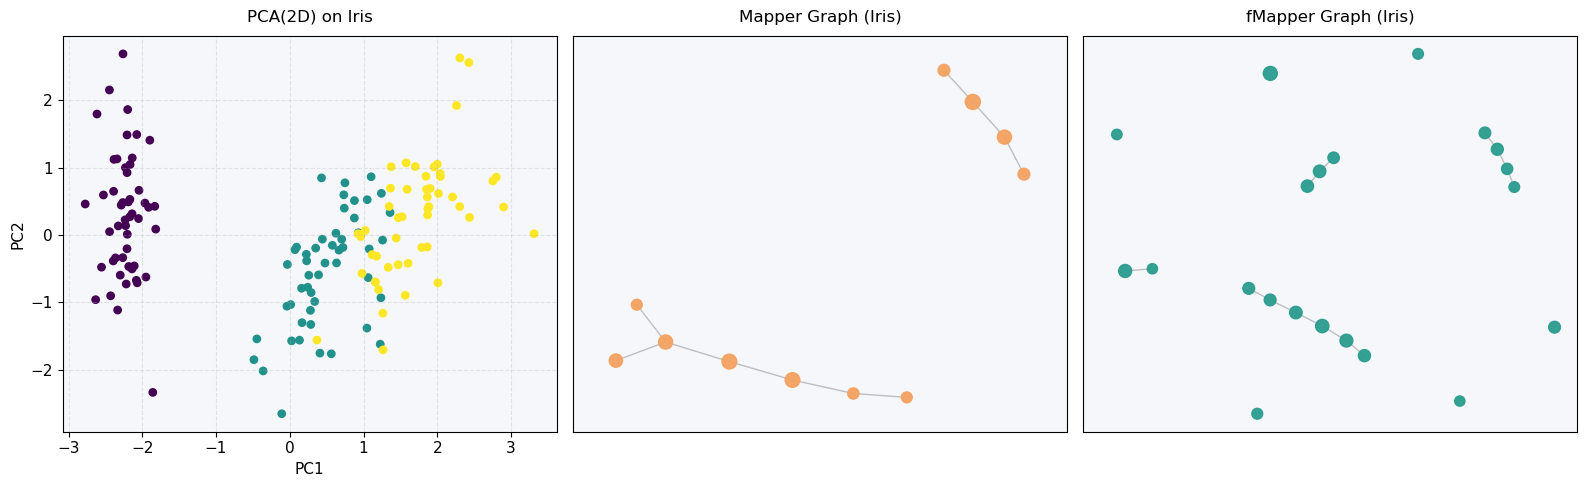

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 9 — Aplicación a Iris: PCA vs Mapper vs fMapper
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: Aplica los tres métodos al dataset Iris (3 especies
# de flores, 4 features) y los compara visualmente.
#
# OBJETIVO: ver la fuerza de Mapper en un caso REAL donde hay
# clases conocidas → podemos comparar calidad de la estructura
# capturada por cada método.
#
# MÉTODOS COMPARADOS:
#   1. PCA 2D + 1-NN (baseline clásico)
#   2. Mapper con lens = primera coordenada (sepal length)
#   3. fMapper con lens = UMAP 1D (aprendida)
#
# MÉTRICAS:
#   - Accuracy 1-NN: qué tan separables son las clases en PCA 2D
#   - Silhouette:   qué tan bien definidos están los clusters
#   - Estadísticas del grafo: β₀, β₁ de Mapper y fMapper
# ═══════════════════════════════════════════════════════════════

# ── Paso 1: cargar Iris y estandarizar ────────────────────
iris = load_iris()
# Estandarizamos ANTES de cualquier cosa (importante para distancias)
Xi = StandardScaler().fit_transform(iris.data)   # features
yi = iris.target                                  # etiquetas (0,1,2)

# ── Paso 2: baseline PCA 2D ───────────────────────────────
# Reducir a 2D con PCA para poder graficar
X_pca2 = PCA(n_components=2).fit_transform(Xi)

# Evaluar qué tan separables son las clases en el espacio PCA:
# 1-NN con validación cruzada 5-fold
pca_knn = cross_val_score(
    KNeighborsClassifier(n_neighbors=7),    # 7-NN
    X_pca2,                                  # datos en PCA 2D
    yi,                                      # etiquetas
    cv=5                                     # 5-fold CV
).mean()  # promedio de las 5 folds

# Silhouette score: mide qué tan bien separados están los clusters
# Rango: -1 (mal) a +1 (bien separados)
sil_pca = silhouette_score(X_pca2, yi)

# ── Paso 3: Mapper con lens simple (coordenada 0 = sepal length) ──
# Xi[:, [0]] → primera columna manteniendo forma (n, 1)
lens_mapper_iris = Xi[:, [0]]

g_mapper_iris, G_mapper_iris = build_mapper(
    Xi,
    lens_mapper_iris,
    n_cubes=10,
    overlap=0.35,
    clusterer=DBSCAN(eps=0.65, min_samples=4)   # eps mayor porque datos estandarizados
)

# ── Paso 4: fMapper con lens UMAP aprendida ────────────────
# UMAP 1D sobre los datos estandarizados
lens_f_iris = umap.UMAP(
    n_components=1,
    n_neighbors=15,
    min_dist=0.1,
    random_state=7
).fit_transform(Xi)

# fMapper con KMeans(n_clusters=3) porque sabemos que hay 3 especies
g_fmapper_iris, G_fmapper_iris = build_mapper(
    Xi,
    lens_f_iris,
    n_cubes=10,
    overlap=0.35,
    clusterer=MiniBatchKMeans(n_clusters=3, random_state=7, batch_size=64),
)

# ── Paso 5: imprimir resultados numéricos ──────────────────
print(f"PCA baseline: 5-fold 1-NN accuracy={pca_knn:.3f}, silhouette={sil_pca:.3f}")
print("Mapper graph stats (Iris):",  graph_stats(G_mapper_iris))
print("fMapper graph stats (Iris):", graph_stats(G_fmapper_iris))

# ── Paso 6: comparación visual lado a lado ─────────────────
# 1 fila × 3 columnas: PCA | Mapper | fMapper
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Subplot 0: PCA 2D ─────────────────────────────────────
# Scatter coloreado por especie (yi)
axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1], c=yi, s=28, cmap="viridis")
beautify(axes[0], "PCA(2D) on Iris", "PC1", "PC2")

# ── Subplot 1: grafo de Mapper ────────────────────────────
pos_m = nx.spring_layout(G_mapper_iris, seed=7)
nx.draw_networkx_edges(G_mapper_iris, pos_m, ax=axes[1], alpha=0.35, width=1.0, edge_color="#555555")
nx.draw_networkx_nodes(
    G_mapper_iris,
    pos_m,
    ax=axes[1],
    node_size=[50 + 2.2 * G_mapper_iris.nodes[n]["size"] for n in G_mapper_iris.nodes()],
    node_color=PALETTE["orange"],
    alpha=0.95,
)
beautify(axes[1], "Mapper Graph (Iris)")
axes[1].set_xticks([])
axes[1].set_yticks([])

# ── Subplot 2: grafo de fMapper ───────────────────────────
pos_f = nx.spring_layout(G_fmapper_iris, seed=7)
nx.draw_networkx_edges(G_fmapper_iris, pos_f, ax=axes[2], alpha=0.35, width=1.0, edge_color="#555555")
nx.draw_networkx_nodes(
    G_fmapper_iris,
    pos_f,
    ax=axes[2],
    node_size=[50 + 2.2 * G_fmapper_iris.nodes[n]["size"] for n in G_fmapper_iris.nodes()],
    node_color=PALETTE["green"],
    alpha=0.95,
)
beautify(axes[2], "fMapper Graph (Iris)")
axes[2].set_xticks([])
axes[2].set_yticks([])

plt.tight_layout()
plt.show()

Grafo Mapper (naranja, centro):
  Solo 11 nodos y 2 componentes
  → muy simple, no captura bien las 3 especies
  → β₀=2 pero hay 3 clases → falta información

Grafo fMapper (verde, derecha):
  21 nodos pero comp=10 → muy fragmentado
  → cada nodo casi no conectado con los demás
  → tampoco captura bien la estructura

  → necesitarías un sweep para encontrar n_cubes y overlap óptimos

## 7. How to Interpret Mapper Graphs and Topology

Interpretation checklist:
1. **Connected components**: disconnected parts suggest distinct regimes or subpopulations.
2. **Cycles (loops)**: often indicate circular or periodic structure in the data manifold.
3. **High-degree nodes**: likely transition regions or bridges between groups.
4. **Node size**: local density or support of that region.
5. **Node label composition**: purity tells if a node corresponds to one cluster/class or is mixed.

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELDA 10 — Análisis de pureza de nodos (node purity)
# ═══════════════════════════════════════════════════════════════
# CONTENIDO: Define una función que mide qué tan 'puro' es cada
# nodo respecto a las etiquetas de clase conocidas.
#
# QUÉ ES LA PUREZA:
#   Un nodo contiene varios puntos. Cada punto tiene una etiqueta
#   (0, 1, 2 para las 3 especies de Iris).
#   
#   Pureza = fracción del label MAYORITARIO en el nodo
#   
#   Ejemplos:
#     Nodo con [10 setosa, 0 versicolor, 0 virginica] → pureza=1.0 ✅
#     Nodo con [5 setosa, 5 versicolor, 0 virginica] → pureza=0.5 ⚠️
#     Nodo con [3 setosa, 3 versicolor, 3 virginica] → pureza=0.33 ❌
#
# OBJETIVO: identificar los nodos MIXTOS (baja pureza) que son
# las zonas de transición o ambigüedad — los más interesantes
# para interpretación.
# ═══════════════════════════════════════════════════════════════

def node_purity(graph_dict, labels):
    """
    Calcula la pureza de cada nodo y una pureza global ponderada.
    
    Parámetros:
      graph_dict: el diccionario devuelto por kmapper
                  (tiene 'nodes' con {id: [indices de puntos]})
      labels:     array con la etiqueta de cada punto
    
    Devuelve:
      weighted:  pureza global ponderada por tamaño de nodo
      detail_df: DataFrame con detalle por nodo
                 ordenado de menos a más puro (mixtos primero)
    """
    purities = []  # lista de tuplas (tamaño, pureza) para promedio ponderado
    details = []   # lista de tuplas para el DataFrame detallado
    
    # Iterar sobre cada nodo del grafo
    for node, idx in graph_dict["nodes"].items():
        # idx = lista de índices de los puntos que caen en este nodo
        
        # Tomar las etiquetas de esos puntos
        node_labels = labels[idx]
        
        # Contar cuántos puntos hay de cada clase
        # minlength asegura que el array tenga al menos una entrada
        # por cada clase posible (aunque sea 0)
        counts = np.bincount(node_labels, minlength=len(np.unique(labels)))
        
        # Pureza = el label más frecuente / total de puntos en el nodo
        purity = counts.max() / counts.sum()
        
        # Guardar para el promedio ponderado y el detalle
        purities.append((len(idx), purity))
        details.append((node, len(idx), purity, counts.tolist()))
    
    # Caso borde: grafo vacío
    if not purities:
        return 0.0, pd.DataFrame(columns=["node", "size", "purity", "label_counts"])
    
    # Pureza global PONDERADA por tamaño de nodo
    # Los nodos grandes pesan más en el promedio
    weighted = np.average(
        [p for _, p in purities],      # valores de pureza
        weights=[s for s, _ in purities]  # pesos = tamaños
    )
    
    # DataFrame detallado ordenado:
    #   - primero por pureza ASCENDENTE (mixtos primero)
    #   - luego por tamaño DESCENDENTE (grandes primero)
    # Así vemos primero los nodos MIXTOS y GRANDES = los más problemáticos
    detail_df = pd.DataFrame(
        details,
        columns=["node", "size", "purity", "label_counts"]
    ).sort_values(
        ["purity", "size"],
        ascending=[True, False]
    )
    
    return weighted, detail_df


# ── Aplicar node_purity a Mapper y fMapper de Iris ─────────
pur_mapper,  detail_mapper  = node_purity(g_mapper_iris,  yi)
pur_fmapper, detail_fmapper = node_purity(g_fmapper_iris, yi)

# Imprimir pureza global — qué método separa mejor las clases
print(f"Weighted node purity (Mapper):  {pur_mapper:.3f}")
print(f"Weighted node purity (fMapper): {pur_fmapper:.3f}")
# ESPERADO: fMapper suele tener mejor pureza porque su lens
# aprende la geometría no lineal

# Mostrar los 5 nodos más mixtos de Mapper (posibles puentes/transiciones)
print("\nMost mixed Mapper nodes:")
display(detail_mapper.head(5))

# Mismo para fMapper
print("Most mixed fMapper nodes:")
display(detail_fmapper.head(5))
# INTERPRETACIÓN:
# Los nodos con baja pureza son las ZONAS DE TRANSICIÓN entre clases
# — suelen ser los más interesantes clínicamente/científicamente
# porque represent
# 
# an datos AMBIGUOS o intermedios.

Weighted node purity (Mapper):  0.859
Weighted node purity (fMapper): 0.887

Most mixed Mapper nodes:


,node,size,purity,label_counts
8,cube6_cluster0,28,0.642857,"[0, 10, 18]"
7,cube5_cluster0,29,0.655172,"[0, 10, 19]"
6,cube4_cluster0,24,0.708333,"[0, 17, 7]"
1,cube1_cluster0,31,1.000000,"[31, 0, 0]"
2,cube2_cluster0,24,1.000000,"[24, 0, 0]"


Most mixed fMapper nodes:


,node,size,purity,label_counts
4,cube1_cluster1,13,0.538462,"[0, 6, 7]"
3,cube1_cluster0,16,0.625000,"[0, 10, 6]"
2,cube0_cluster2,12,0.666667,"[0, 8, 4]"
10,cube3_cluster1,4,0.750000,"[0, 3, 1]"
8,cube2_cluster2,19,0.842105,"[0, 16, 3]"


In [13]:
# Evaluar Mapper como clasificador:
# 1. Cada punto hereda la etiqueta mayoritaria de su nodo
# 2. Comparas esa etiqueta predicha con la real

# Pseudocódigo:
predicciones = []
for punto_i in range(n_puntos):
    # encontrar en qué nodo está el punto i
    for nodo, miembros in graph["nodes"].items():
        if punto_i in miembros:
            # predecir = label mayoritario del nodo
            pred = label_mayoritario(nodo)
            predicciones.append(pred)
            break

accuracy = (predicciones == labels_reales).mean()

NameError: name 'n_puntos' is not defined

## Summary and Exercises

### Summary
- Mapper transforms local clu sters over an overlapping lens cover into a graph.
- fMapper uses a learned lens and can reveal cleaner global organization in nonlinear data.
- Hyperparameters strongly affect topology: node count, connectivity, and apparent loops.
- Interpretation should combine topology (components/cycles/bridges) and node composition (purity).

### Exercises
1. Repeat the Mapper sweep on `make_moons` and identify when the graph breaks into many components.
2. In fMapper, vary UMAP `n_neighbors` from 3 to 80 and describe how loop structure changes.
3. Replace local clusterers with `AgglomerativeClustering` and compare node purity.
4. Build an interpretation report: for each high-degree node, describe whether it is a bridge, hub, or noisy artifact.

=== TABLA DE BARRIDO EN MOONS ===


,nodes,edges,components,cycles,avg_degree,n_cubes,overlap
0,13,11,2,0,1.692308,6,0.1
1,13,11,2,0,1.692308,6,0.2
2,15,13,2,0,1.733333,6,0.3
3,16,14,2,0,1.750000,6,0.5
4,24,22,2,0,1.833333,10,0.1
5,24,22,2,0,1.833333,10,0.2
6,24,22,2,0,1.833333,10,0.3
7,23,21,2,0,1.826087,10,0.5
8,37,34,3,0,1.837838,16,0.1
9,38,36,2,0,1.894737,16,0.2


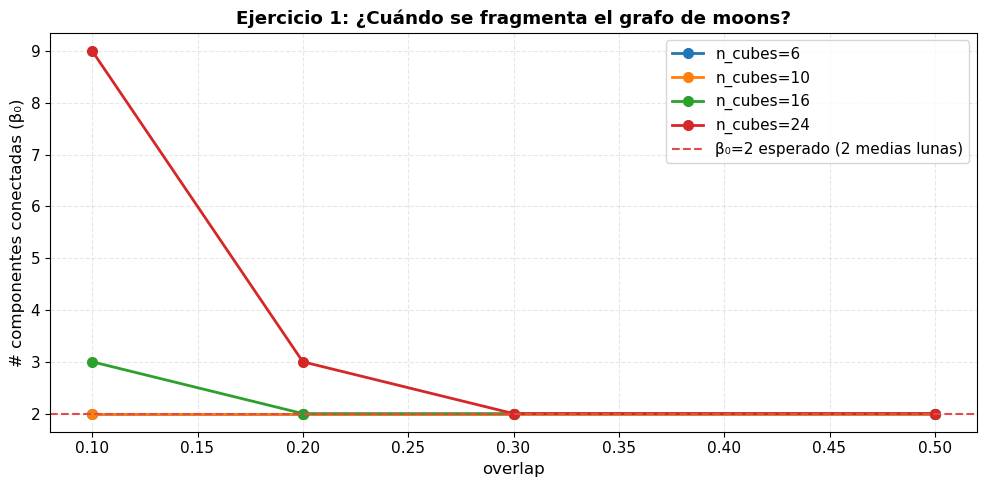


=== VEREDICTO EJERCICIO 1 ===
El grafo se FRAGMENTA (β₀ > 3) en 1 combinaciones:
  n_cubes=24.0, overlap=0.1 → 9.0 componentes

Patrón observado:
  → Cuando overlap es muy bajo (0.10-0.20)
    los intervalos NO COMPARTEN puntos
    → no hay aristas entre ellos
    → el grafo se ROMPE en muchas partes


In [12]:
"""
═══════════════════════════════════════════════════════════════
EJERCICIO 1: Mapper sweep sobre make_moons
═══════════════════════════════════════════════════════════════

ENUNCIADO:
  Repeat the Mapper sweep on make_moons and identify
  when the graph breaks into many components.

OBJETIVO:
  Ver cómo los hiperparámetros del cover (n_cubes, overlap)
  afectan la conectividad del grafo sobre medias lunas.

QUÉ SE ESPERA:
  - overlap bajo (0.15) → grafo FRAGMENTADO (muchas componentes)
  - overlap alto  (0.50) → grafo CONECTADO (pocas componentes)
  - n_cubes alto  → más nodos, pero también más componentes
    si el overlap es pequeño
  - Las medias lunas tienen 2 componentes naturales
    (las dos medias lunas) → esperamos β₀ = 2 en el caso ideal
═══════════════════════════════════════════════════════════════
"""

# ── Preparar los datos de las medias lunas ─────────────────
Xm = StandardScaler().fit_transform(X_moons)
# Estandarizamos los datos para que DBSCAN funcione bien

lens_moons = Xm[:, [1]]
# Lens = coordenada Y (altura)
# → corta horizontalmente las dos medias lunas

# ── Barrido de hiperparámetros ─────────────────────────────
moons_sweep_rows = []  # lista para guardar resultados de cada combo

for n_cubes in [6, 10, 16, 24]:
# Probamos 4 valores de n_cubes (agregué 24 para ver extremo)
    
    for overlap in [0.10, 0.20, 0.30, 0.50]:
    # 4 valores de overlap incluyendo uno muy bajo (0.10)
    
        # Construir Mapper con estos parámetros
        _, Gtmp = build_mapper(
            Xm,                                           # datos estandarizados
            lens_moons,                                    # lens = coord Y
            n_cubes=n_cubes,                               # variable
            overlap=overlap,                               # variable
            clusterer=DBSCAN(eps=0.22, min_samples=6)      # DBSCAN fijo
        )
        
        # Calcular estadísticas del grafo
        st = graph_stats(Gtmp)
        st.update({"n_cubes": n_cubes, "overlap": overlap})
        moons_sweep_rows.append(st)

# Convertir a DataFrame para ver la tabla
moons_sweep = pd.DataFrame(moons_sweep_rows) \
    .sort_values(["n_cubes", "overlap"]) \
    .reset_index(drop=True)

print("=== TABLA DE BARRIDO EN MOONS ===")
display(moons_sweep)

# ── Visualizar cuándo se fragmenta ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Un color por cada n_cubes
for nc in moons_sweep["n_cubes"].unique():
    sub = moons_sweep[moons_sweep["n_cubes"] == nc]
    # Filtra solo las filas con ese n_cubes
    
    ax.plot(sub["overlap"], sub["components"],
            'o-', lw=2, ms=7,
            label=f'n_cubes={nc}')
    # Gráfica: overlap vs # componentes

ax.axhline(2, color='#E24B4A', ls='--', lw=1.5,
           label='β₀=2 esperado (2 medias lunas)')
# Línea horizontal en el valor ideal

ax.set_xlabel('overlap', fontsize=12)
ax.set_ylabel('# componentes conectadas (β₀)', fontsize=12)
ax.set_title('Ejercicio 1: ¿Cuándo se fragmenta el grafo de moons?',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Encontrar el punto de quiebre ─────────────────────────
print("\n=== VEREDICTO EJERCICIO 1 ===")
fragmented = moons_sweep[moons_sweep["components"] > 3]
# Filas donde hay más de 3 componentes = grafo fragmentado

if len(fragmented) > 0:
    print(f"El grafo se FRAGMENTA (β₀ > 3) en {len(fragmented)} combinaciones:")
    for _, row in fragmented.iterrows():
        print(f"  n_cubes={row['n_cubes']}, overlap={row['overlap']} "
              f"→ {row['components']} componentes")
    
    print("\nPatrón observado:")
    print("  → Cuando overlap es muy bajo (0.10-0.20)")
    print("    los intervalos NO COMPARTEN puntos")
    print("    → no hay aristas entre ellos")
    print("    → el grafo se ROMPE en muchas partes")
else:
    print("El grafo nunca se fragmenta en estas combinaciones")


Inestable = el resultado cambia mucho con
pequeños cambios de parámetros

Ejemplo de la tabla:
  n_neighbors=5,  min_dist=0.0 → cycles=2
  n_neighbors=5,  min_dist=0.2 → cycles=2
  n_neighbors=5,  min_dist=0.6 → cycles=3  ← cambió!

→ el número de ciclos NO es consistente
→ no puedo confiar en que β₁=2 es real

Estable sería:
  n_neighbors=10, min_dist=0.0 → cycles=2
  n_neighbors=10, min_dist=0.2 → cycles=2
  n_neighbors=10, min_dist=0.6 → cycles=2
  → siempre da 2 → puedo confiar ✅

En la práctica:
  haz un sweep y mira cuándo el resultado
  se repite consistentemente → eso es tu respuesta

A) Si tienes etiquetas (como Iris):
   → usa node_purity
   → mayor purity = mejor ✅

B) Si NO tienes etiquetas:
   → compara resultados con diferentes parámetros
   → busca el grafo más ESTABLE:
     si al cambiar overlap=0.3→0.35 el grafo
     cambia completamente → inestable ❌
     si se mantiene similar → confiable ✅

C) Validación topológica:
   → si sospechas que hay 2 clusters →
     busca n_cubes/overlap que den components=2
     de forma robusta en varios parámetros